# Flood prediction model in Veracruz through the detection of urban topography using Artificial Vision algorithms

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import io
from PIL import Image

# Botón para cargar la imagen de ejemplo
print("Selecciona la imagen satelital de Veracruz para el análisis:")
uploaded = files.upload()

for filename in uploaded.keys():
    # Convertir a formato OpenCV
    image_raw = Image.open(io.BytesIO(uploaded[filename]))
    image_cv2 = cv2.cvtColor(np.array(image_raw), cv2.COLOR_RGB2BGR)
    print(f"Imagen '{filename}' cargada con éxito.")

Selecciona la imagen satelital de Veracruz para el análisis:


Saving ImagenTest_GEarh_BR01.png to ImagenTest_GEarh_BR01 (1).png
Imagen 'ImagenTest_GEarh_BR01 (1).png' cargada con éxito.


In [23]:
# --- MÓDULO 1: ADQUISICIÓN Y GSD ---
def normalize_gsd(image, original_res=0.3, target_gsd=0.5):
    scale_factor = original_res / target_gsd
    width = int(image.shape[1] * scale_factor)
    height = int(image.shape[0] * scale_factor)
    return cv2.resize(image, (width, height), interpolation=cv2.INTER_AREA)

# --- MÓDULO 2: SEGMENTACIÓN (U-NET SIMULADA PARA DEMO) ---
def get_dummy_soil_mask(image):
    # En un entorno real, aquí cargarías el modelo .h5 entrenado
    # Para la demo, simulamos la detección de zonas urbanas (impermeables) mediante umbral de grises
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 120, 1, cv2.THRESH_BINARY)
    return mask

# --- MÓDULO 3: SIMULACIÓN DE INUNDACIÓN ---
def run_flood_simulation(image, soil_mask, water_level_m):
    # Generamos un mapa de elevación sintético basado en gradientes (para fines de la actividad)
    h, w = soil_mask.shape
    x, y = np.meshgrid(np.linspace(0, 5, w), np.linspace(0, 5, h))
    depth_map = np.sin(x) + np.cos(y) + 2 # Altitud simulada entre 0 y 4 metros

    # Lógica de inundación: Elevación baja Y Suelo impermeable
    flood_mask = ((depth_map < water_level_m) & (soil_mask == 1)).astype(np.uint8)

    # Heatmap
    heatmap = cv2.applyColorMap(flood_mask * 255, cv2.COLORMAP_JET)
    # Superposición (Overlay) con la imagen original
    overlay = cv2.addWeighted(image, 0.7, heatmap, 0.3, 0)
    return overlay, flood_mask

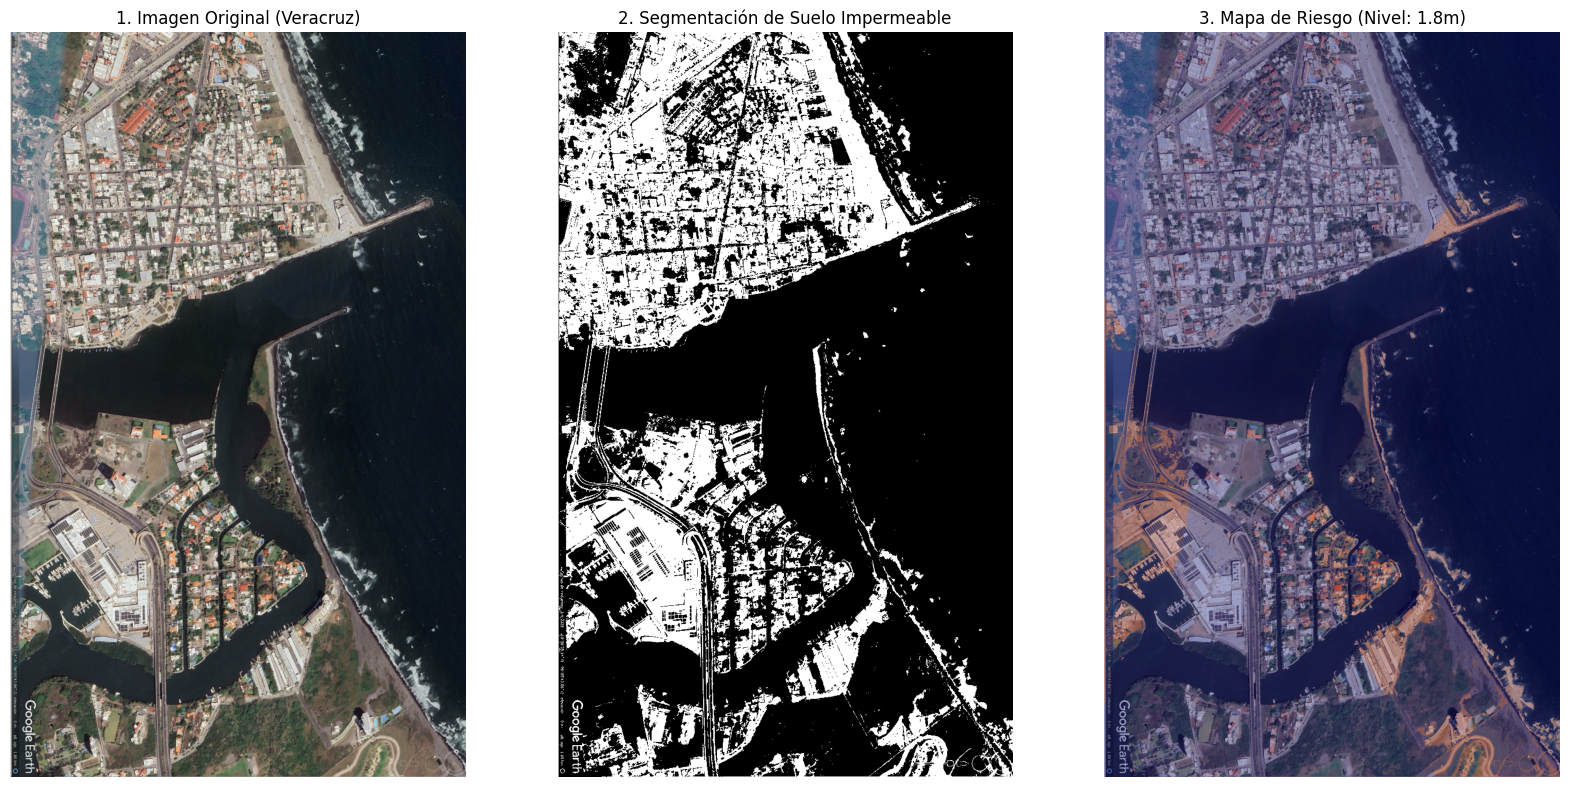

In [25]:
# Configuración de la simulación
NIVEL_AGUA = 1.8  # metros

# Procesamiento
img_norm = normalize_gsd(image_cv2)
mask_suelo = get_dummy_soil_mask(img_norm)
resultado_visual, mascara_binaria = run_flood_simulation(img_norm, mask_suelo, NIVEL_AGUA)

# Visualización
plt.figure(figsize=(20, 10))

plt.subplot(1, 3, 1)
plt.title("1. Imagen Original (Veracruz)")
plt.imshow(cv2.cvtColor(img_norm, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("2. Segmentación de Suelo Impermeable")
plt.imshow(mask_suelo, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title(f"3. Mapa de Riesgo (Nivel: {NIVEL_AGUA}m)")
plt.imshow(cv2.cvtColor(resultado_visual, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.show()